# 07 — Budget-penalty sweep

**Sweep 4.** Fixed canonical instance (n=16, K=4, p=3). Vary the QUBO
budget-penalty coefficient `A` on a dense logarithmic grid of 8 points
from $10^{-2}$ to $\sim 30$, with 50 multi-start COBYLA seeds per `A`.

Why this exists: in notebook 03 the most-probable bitstring at A=0.5
(the project default) is `1111111111111111` — i.e. the budget penalty
doesn't dominate, so QAOA happily settles on infeasible all-ones or
single-asset solutions. If P(feasible) and P(optimum) rise as `A` grows,
the failure of QAOA in 03/04/05/06 is a tuning issue, not a method issue.
The denser grid + larger restart budget (50, not 10) replaces the earlier
4-point sweep whose mid-range dip was almost certainly restart variance.

All values share lam=2.0 and K=4 with the rest of the project.
Results cache to `results/penalty_sweep.json`.

> **Runtime:** ~30 min on Colab CPU from scratch (instant on cache hit).

In [1]:
# === Bootstrap (Colab + local) ===
import os, urllib.request as _u
exec((open('../scripts/bootstrap.py') if os.path.exists('../scripts/bootstrap.py') else _u.urlopen('https://raw.githubusercontent.com/egil10/fys5419/main/project2/code/scripts/bootstrap.py')).read())

# === Project imports ===
import json
import numpy as np
import pandas as pd

from scripts.colab     import out_dir
from scripts.data      import load_universe
from scripts.portfolio import PortfolioProblem, DEFAULTS
from scripts.classical import brute_force
from scripts.qaoa      import solve, make_hamiltonians
from scripts.metrics   import prob_optimal, prob_feasible, scaled_ratio, gap

RESULTS = out_dir('results')
print(f'Results will be saved to: {RESULTS}')

> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5419/project2/code/results


In [2]:
# === Canonical instance: n=16, K=4, p=3, lam=2.0 ===
K          = DEFAULTS['K_AT_16']
LAM        = DEFAULTS['lam']
P          = 3
N_RESTARTS = 50                 # bumped from 10 -> 50 (same logic as 04, 06)

# 8 log-spaced points from 0.01 to ~30, replacing the earlier 4-point grid.
# The denser grid lets us see (a) where the budget penalty stops being
# dominated by the data scale (mu, lam Sigma), (b) the knee where
# P(optimum) starts to fall again because the penalty is so large that
# COBYLA is searching a near-flat region between feasible bitstrings.
A_VALUES = list(np.logspace(-2, 1.5, 8))
print(f'sweeping A in {[round(a, 4) for a in A_VALUES]} at lam={LAM}, K={K}, p={P}')
print(f'restart budget per A: {N_RESTARTS}')

sweeping A in [np.float64(0.01), np.float64(0.0316), np.float64(0.1), np.float64(0.3162), np.float64(1.0), np.float64(3.1623), np.float64(10.0), np.float64(31.6228)] at lam=2.0, K=4, p=3
restart budget per A: 50


In [3]:
r = load_universe()
cache = RESULTS / 'penalty_sweep.json'

if cache.exists():
    rows = json.loads(cache.read_text())
    print(f'loaded {cache.name}')
else:
    rows = []
    for A in A_VALUES:
        pf = PortfolioProblem(r.mu, r.Sigma, lam=LAM, A=float(A), K=K,
                              tickers=r.tickers)
        bf = brute_force(pf)

        # H_C spectrum endpoints in COST units.
        _, _, _, _, _, HC = make_hamiltonians(pf)
        e_opt   = float(HC.min())
        e_worst = float(HC.max())

        qres = solve(pf, p=P, n_restarts=N_RESTARTS, seed=42)

        rows.append({
            'A':           float(A),
            'bf_cost':     bf.cost,
            'bf_bitstring': bf.bitstring,
            'qaoa_energy': float(qres['energy']),
            'ratio':       scaled_ratio(qres['energy'], e_opt, e_worst),
            'gap_rel':     gap(qres['energy'], e_opt),
            'p_optimal':   prob_optimal(qres['probs'], bf.x),
            'p_feasible':  prob_feasible(qres['probs'], pf.n, pf.K),
            'e_opt':       e_opt,
            'e_worst':     e_worst,
            'spread':      e_worst - e_opt,
        })
        print(f'  A={A:>6.2f}: bf={bf.cost:+.4f}  qaoa_E={qres["energy"]:+.4f}  '
              f'ratio={rows[-1]["ratio"]:.4f}  '
              f'P(opt)={rows[-1]["p_optimal"]:.4f}  '
              f'P(feas)={rows[-1]["p_feasible"]:.4f}')

    cache.write_text(json.dumps(rows, indent=2))
    print(f'saved -> {cache.name}')

pd.DataFrame(rows)

  A=  0.01: bf=-0.0014  qaoa_E=+0.0236  ratio=0.9848  P(opt)=0.0003  P(feas)=0.3687
  A=  0.03: bf=-0.0014  qaoa_E=+0.0367  ratio=0.9920  P(opt)=0.0003  P(feas)=0.5002
  A=  0.10: bf=-0.0014  qaoa_E=+0.0573  ratio=0.9960  P(opt)=0.0004  P(feas)=0.7550
  A=  0.32: bf=-0.0014  qaoa_E=+0.2037  ratio=0.9955  P(opt)=0.0005  P(feas)=0.9053
  A=  1.00: bf=-0.0014  qaoa_E=+2.4454  ratio=0.9830  P(opt)=0.0002  P(feas)=0.4499
  A=  3.16: bf=-0.0014  qaoa_E=+1.9836  ratio=0.9956  P(opt)=0.0005  P(feas)=0.7312
  A= 10.00: bf=-0.0014  qaoa_E=+8.8933  ratio=0.9938  P(opt)=0.0002  P(feas)=0.4945
  A= 31.62: bf=-0.0014  qaoa_E=+48.8369  ratio=0.9893  P(opt)=0.0002  P(feas)=0.5097
saved -> penalty_sweep.json


,A,bf_cost,bf_bitstring,qaoa_energy,ratio,gap_rel,p_optimal,p_feasible,e_opt,e_worst,spread
0,0.010000,-0.001404,0010000010010001,0.023646,0.984793,17.836696,0.000336,0.368663,-0.001404,1.645957,1.647362
1,0.031623,-0.001404,0010000010010001,0.036652,0.992007,27.097207,0.000337,0.500150,-0.001404,4.759637,4.761042
2,0.100000,-0.001404,0010000010010001,0.057329,0.995979,41.819134,0.000449,0.754998,-0.001404,14.605957,14.607362
3,0.316228,-0.001404,0010000010010001,0.203667,0.995517,146.014799,0.000492,0.905298,-0.001404,45.742756,45.744160
4,1.000000,-0.001404,0010000010010001,2.445399,0.983033,1742.172579,0.000232,0.449869,-0.001404,144.205957,144.207362
5,3.162278,-0.001404,0010000010010001,1.983553,0.995643,1413.329025,0.000497,0.731172,-0.001404,455.573940,455.575345
6,10.000000,-0.001404,0010000010010001,8.893339,0.993824,6333.233799,0.000213,0.494498,-0.001404,1440.205957,1440.207362
7,31.622777,-0.001404,0010000010010001,48.836912,0.989275,34773.850718,0.000204,0.509687,-0.001404,4553.885788,4553.887192


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


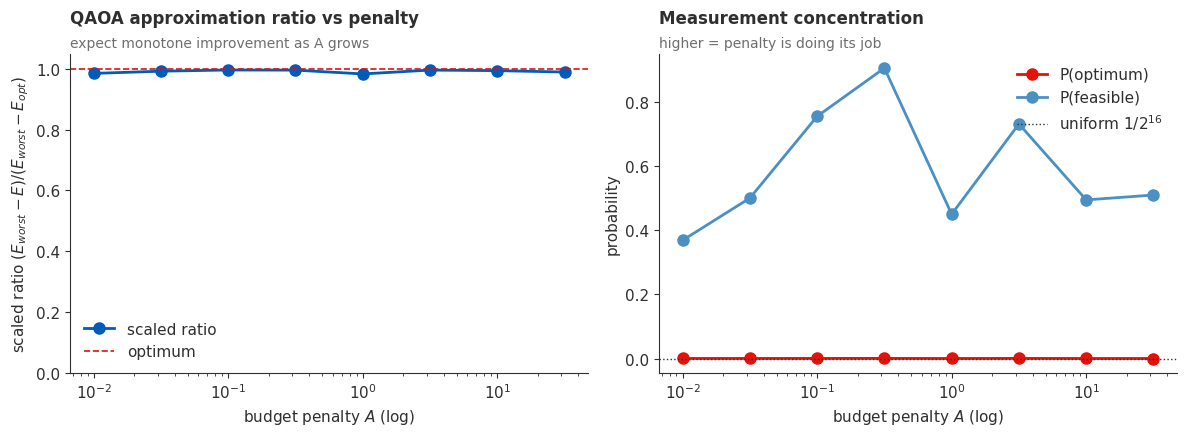

In [4]:
import matplotlib.pyplot as plt
from scripts.plotting import apply_style, PALETTE, title, fig_path
apply_style()

df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogx(df.A, df.ratio, 'o-', color=PALETTE['blue'], lw=2, ms=8, label='scaled ratio')
axes[0].axhline(1.0, color=PALETTE['red'], ls='--', lw=1.2, label='optimum')
axes[0].set_xlabel(r'budget penalty $A$ (log)')
axes[0].set_ylabel(r'scaled ratio $(E_{worst} - E)/(E_{worst} - E_{opt})$')
axes[0].set_ylim(0.0, 1.05)
title(axes[0], 'QAOA approximation ratio vs penalty', 'expect monotone improvement as A grows')
axes[0].legend(); axes[0].grid(False)

axes[1].semilogx(df.A, df.p_optimal,  'o-', color=PALETTE['red'],        lw=2, ms=8, label='P(optimum)')
axes[1].semilogx(df.A, df.p_feasible, 'o-', color=PALETTE['blue_muted'], lw=2, ms=8, label='P(feasible)')
axes[1].axhline(1.0/(1 << 16), color=PALETTE['charcoal'], ls=':', lw=1, label=r'uniform $1/2^{16}$')
axes[1].set_xlabel(r'budget penalty $A$ (log)')
axes[1].set_ylabel('probability')
title(axes[1], 'Measurement concentration', 'higher = penalty is doing its job')
axes[1].legend(); axes[1].grid(False)

plt.tight_layout()
fig.savefig(fig_path('compare', 'penalty_sweep'), bbox_inches='tight')
plt.show()